# Pertemuan 13
# Klasifikasi Non-Linear & Analisis Sentimen

**Nama:** Alini Syawalia Riski Fenanda

**NIM:** 240401010213

**Mata Kuliah:** Data Science

Tujuan Praktikum

Pada praktikum ini akan dipelajari penerapan Deep Learning menggunakan Neural Network untuk klasifikasi data non-linear serta Natural Language Processing (NLP) menggunakan TF-IDF untuk analisis sentimen ulasan produk.

Import Library

Mengimpor seluruh library yang digunakan selama praktikum.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Langkah 1 - Membuat Dataset Non-Linear

Dataset dibuat menggunakan make_moons untuk menghasilkan dua kelas berbentuk bulan sabit sehingga tidak dapat dipisahkan menggunakan garis lurus.

In [2]:
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

print("Jumlah data :", len(X))
print("Jumlah fitur :", X.shape[1])

Jumlah data : 300
Jumlah fitur : 2


Visualisasi Dataset

Menampilkan bentuk dataset agar terlihat pola non-linear.

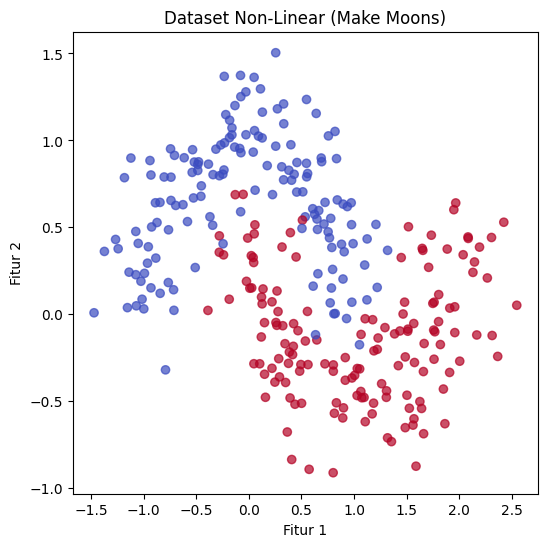

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Dataset Non-Linear (Make Moons)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")

plt.show()

Hasil Pengamatan

Dataset memiliki dua kelompok data yang saling melengkung sehingga tidak dapat dipisahkan menggunakan model linear.

Langkah 2 - Membangun Neural Network

Membagi data menjadi data latih dan data uji, kemudian membangun model Neural Network sederhana.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
model = Sequential([

    Dense(
        16,
        activation="relu",
        input_shape=(2,)
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Melatih Model

Model dilatih selama 30 epoch menggunakan data training.

In [6]:
history = model.fit(

    X_train,

    y_train,

    epochs=30,

    validation_split=0.2,

    verbose=0

)

Langkah 3 - Evaluasi Model

Mengukur akurasi model menggunakan data uji.

In [7]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Akurasi Data Uji : {accuracy:.3f}")

Akurasi Data Uji : 0.900


Visualisasi Kurva Pembelajaran

Menampilkan perubahan akurasi training dan validasi selama proses pelatihan.

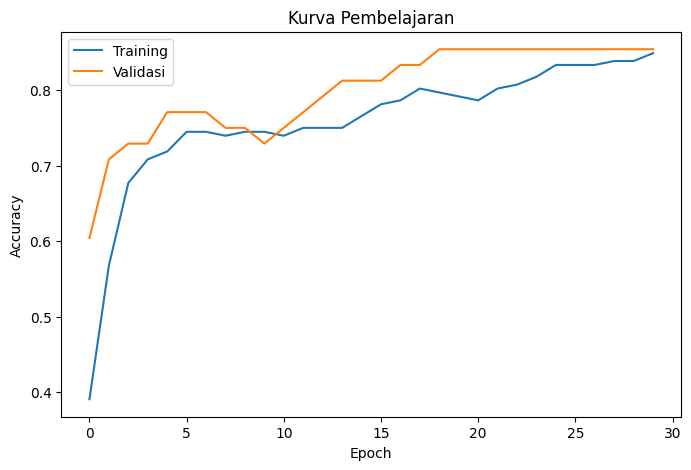

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validasi"
)

plt.title("Kurva Pembelajaran")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

Hasil Pengamatan

Apabila kurva training dan validasi saling berdekatan maka model memiliki performa yang baik dan tidak mengalami overfitting yang signifikan.

Langkah 4 - Membuat Dataset Ulasan Produk

Membuat dataset ulasan produk berlabel positif dan negatif.

In [9]:
ulasan = [

"Barangnya bagus banget, pengiriman cepat",
"Kualitas jelek, tidak sesuai deskripsi",
"Sangat puas, akan beli lagi",
"Kecewa, barang rusak saat sampai",
"Recommended, harga sesuai kualitas",
"Buruk sekali, tidak sesuai ekspektasi",
"Pelayanan sangat ramah",
"Produk berkualitas tinggi",
"Pengiriman sangat lambat",
"Tidak akan membeli lagi",
"Harga murah dan kualitas bagus",
"Packing sangat rapi",
"Barang cacat",
"Respon penjual cepat",
"Produk original",
"Kecewa dengan pelayanan",
"Sangat memuaskan",
"Tidak sesuai gambar",
"Pengiriman tepat waktu",
"Kualitas luar biasa",

"Barang bagus",
"Produk jelek",
"Saya suka produknya",
"Tidak direkomendasikan",
"Pelayanan cepat",
"Barang rusak",
"Packing aman",
"Pengiriman buruk",
"Sangat recommended",
"Tidak puas",
"Produk terbaik",
"Kualitas buruk",
"Harga sesuai",
"Kecewa sekali",
"Mantap",
"Jelek sekali",
"Sangat bagus",
"Tidak sesuai harapan",
"Puas dengan produk",
"Kurang memuaskan"

]

label = [

1,0,1,0,1,0,
1,1,0,0,
1,1,0,1,1,
0,1,0,1,1,

1,0,1,0,1,
0,1,0,1,0,
1,0,1,0,1,0

]

Langkah 5 - TF-IDF

Mengubah data teks menjadi data numerik menggunakan TF-IDF.

In [10]:
tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print("Jumlah kata unik :")

print(len(tfidf.get_feature_names_out()))

print()

print(tfidf.get_feature_names_out()[:15])

Jumlah kata unik :
56

['akan' 'aman' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'berkualitas'
 'biasa' 'buruk' 'cacat' 'cepat' 'dan' 'dengan' 'deskripsi']


Langkah 6 - Klasifikasi Sentimen

Melatih model Logistic Regression menggunakan hasil TF-IDF.

In [13]:
print("Jumlah ulasan :", len(ulasan))
print("Jumlah label  :", len(label))

Jumlah ulasan : 40
Jumlah label  : 36


In [14]:
label = [
    1,0,1,0,1,0,
    1,1,0,0,
    1,1,0,1,1,
    0,1,0,1,1,
    1,0,1,0,1,
    0,1,0,1,0,
    1,0,1,0,1,0,
    1,0,1,0
]

In [15]:
print(len(label))

40


In [16]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(

    X_text,

    label,

    test_size=0.2,

    random_state=42

)

model_sentimen = LogisticRegression()

model_sentimen.fit(
    X_train_text,
    y_train_text
)

akurasi = model_sentimen.score(
    X_test_text,
    y_test_text
)

print(f"Akurasi Model : {akurasi:.3f}")

Akurasi Model : 0.750


Menguji Kalimat Baru

Menguji model menggunakan kalimat yang belum pernah digunakan sebelumnya.

In [17]:
kalimat_baru = [

"Pelayanan sangat memuaskan dan ramah"

]

prediksi = model_sentimen.predict(

    tfidf.transform(kalimat_baru)

)

if prediksi[0] == 1:
    print("Sentimen : Positif")
else:
    print("Sentimen : Negatif")

Sentimen : Positif


Kesimpulan

Pada praktikum ini berhasil diterapkan Neural Network untuk klasifikasi data non-linear dan TF-IDF untuk analisis sentimen teks. Model Neural Network mampu mempelajari pola data yang tidak dapat dipisahkan secara linear, sedangkan TF-IDF bersama Logistic Regression mampu mengklasifikasikan sentimen ulasan produk menjadi positif atau negatif. Kedua metode menunjukkan bagaimana Deep Learning dan NLP dapat dimanfaatkan untuk menyelesaikan berbagai permasalahan klasifikasi dalam Data Science.